In [1]:
import pandas as pd
import numpy as np

In [ ]:
# Cargar archivos
fed_2020 = pd.read_csv("2020.csv", encoding="latin-1", sep=",")
fed_2021 = pd.read_csv("2021.csv", encoding="latin-1", sep=",")
fed_2022 = pd.read_csv("2022.csv", encoding="latin-1", sep=",")
fed_2023 = pd.read_csv("2023.csv", encoding="latin-1", sep=",")
fed_2024 = pd.read_csv("2024.csv", encoding="latin-1", sep=",")
fed_2025 = pd.read_csv("2025.csv", encoding="latin-1", sep=",")

# Añadir columna Año explícita si no existe
fed_2020["Año"] = 2020
fed_2021["Año"] = 2021
fed_2022["Año"] = 2022
fed_2023["Año"] = 2023
fed_2024["Año"] = 2024
fed_2025["Año"] = 2025

# Unificar
federados = pd.concat([
    fed_2020, fed_2021, fed_2022,
    fed_2023, fed_2024, fed_2025
], ignore_index=True)

# Normalizar NIF
federados["NIF"] = federados["NIF"].str.strip().str.upper()

# Eliminar duplicados por NIF + Año
federados = federados.drop_duplicates(subset=["NIF", "Año"])

In [3]:
fed_2020.dtypes

NIF                               object
Nombre                            object
Apellido1                         object
Apellido2                         object
Sexo                              object
FechaNacimiento                   object
PoblacionDomicilio                object
DescripcionProvinciaDomicilio     object
CodigoPostalDomicilio              int64
Telefono1                         object
Telefono2                         object
Email                             object
Estado                             int64
FechaAltaSolicitud                object
NumeroClub                        object
DescripcionEntidad                object
Temporada                          int64
Modalidad                         object
Categoria                         object
Complementos                      object
ImporteComplemento                 int64
ImporteFMM                       float64
ImporteSeguro                    float64
ImporteFederacionEsp             float64
ImporteDescuento

In [4]:
federados.head()
federados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117000 entries, 0 to 117007
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   NIF                            117000 non-null  object 
 1   Nombre                         117000 non-null  object 
 2   Apellido1                      117000 non-null  object 
 3   Apellido2                      116910 non-null  object 
 4   Sexo                           117000 non-null  object 
 5   FechaNacimiento                117000 non-null  object 
 6   PoblacionDomicilio             117000 non-null  object 
 7   DescripcionProvinciaDomicilio  117000 non-null  object 
 8   CodigoPostalDomicilio          117000 non-null  object 
 9   Telefono1                      116875 non-null  object 
 10  Telefono2                      32113 non-null   object 
 11  Email                          116920 non-null  object 
 12  Estado                         1170

In [ ]:
#carga de accidentes

acc_2020 = pd.read_csv("accidentes_2020.csv")
acc_2021 = pd.read_csv("accidentes_2021.csv")
acc_2022 = pd.read_csv("accidentes_2022.csv")
acc_2023 = pd.read_csv("accidentes_2023.csv")
acc_2024 = pd.read_csv("accidentes_2024.csv")
acc_2025 = pd.read_csv("accidentes_2025.csv")

accidentes = pd.concat([
    acc_2020, acc_2021, acc_2022,
    acc_2023, acc_2024, acc_2025
], ignore_index=True)

# Normalizar NIF
accidentes["NIF"] = accidentes["NIF"].str.strip().str.upper()

# Convertir fecha y extraer año
accidentes["FechaParteAccidente"] = pd.to_datetime(accidentes["FechaParteAccidente"])
accidentes["Año"] = accidentes["FechaParteAccidente"].dt.year

In [6]:
accidentes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3982 entries, 0 to 3981
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   NIF                    3982 non-null   object        
 1   Nombre                 3982 non-null   object        
 2   Apellido1              3982 non-null   object        
 3   Apellido2              3981 non-null   object        
 4   FechaParteAccidente    3982 non-null   datetime64[ns]
 5   FechaAltaParte         3982 non-null   object        
 6   Codigo                 3982 non-null   int64         
 7   DescripcionParte       3982 non-null   object        
 8   Actividad              3982 non-null   object        
 9   Lugar                  3860 non-null   object        
 10  FechaRecepcion         3982 non-null   object        
 11  CentroUrgencias        1604 non-null   object        
 12  Helicoptero            2 non-null      object        
 13  Mac

In [7]:
accidentes_agregados = (
    accidentes
    .groupby(["NIF", "Año"])
    .agg(
        NumeroAccidentesAño=("NIF", "count"),
        Helicoptero=("Helicoptero", lambda x: (x == "SI").any()),
        Hospitalizacion=("CentroHospitalizacion", lambda x: x.notna().any())
    )
    .reset_index()
)

# Convertir booleanos a 0/1
accidentes_agregados["Helicoptero"] = accidentes_agregados["Helicoptero"].astype(int)
accidentes_agregados["Hospitalizacion"] = accidentes_agregados["Hospitalizacion"].astype(int)

In [8]:
# Hacemos un left join de federados con los accidentes

dataset = federados.merge(
    accidentes_agregados,
    on=["NIF", "Año"],
    how="left"
)

# Rellenar NaN (los que no tuvieron accidente)
dataset["NumeroAccidentesAño"] = dataset["NumeroAccidentesAño"].fillna(0)
dataset["Helicoptero"] = dataset["Helicoptero"].fillna(0)
dataset["Hospitalizacion"] = dataset["Hospitalizacion"].fillna(0)

# Crear target binario
dataset["Target"] = np.where(dataset["NumeroAccidentesAño"] > 0, 1, 0)

In [9]:
dataset = dataset.sort_values(["NIF", "Año"])

In [10]:
# accidentes históricos

dataset["AccidentesHistoricos"] = (
    dataset
    .groupby("NIF")["NumeroAccidentesAño"]
    .cumsum()
    .shift(1)
    .fillna(0)
)

In [11]:
# la columna target esta creada, hacemos un value counts para ver el balanceo, el 0 es qu eno tuvieron accidentes mientra que el 1 si.

dataset["Target"].value_counts(normalize=True)

Target
0    0.967897
1    0.032103
Name: proportion, dtype: float64

In [12]:
dataset["Target"].value_counts()

Target
0    113244
1      3756
Name: count, dtype: int64

<Axes: xlabel='Año'>

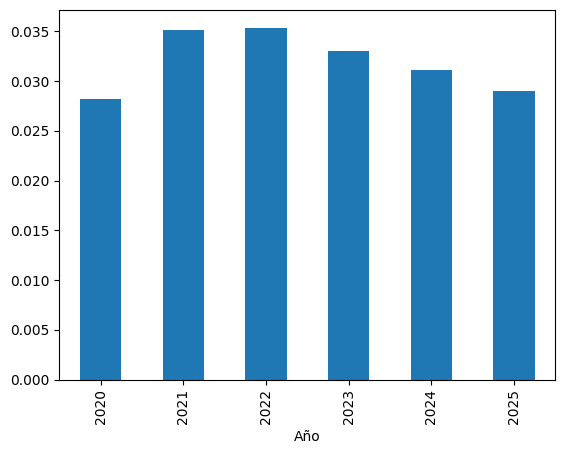

In [13]:
riesgo_por_año = (
    dataset
    .groupby("Año")["Target"]
    .mean()
)

riesgo_por_año.plot(kind="bar")

In [14]:
dataset.groupby("Sexo")["Target"].mean().sort_values(ascending=False)

Sexo
H    0.033183
M    0.029871
Name: Target, dtype: float64

In [15]:
# Creamos variable edad y analizamos

dataset["FechaNacimiento"] = pd.to_datetime(dataset["FechaNacimiento"])

dataset["Edad"] = dataset["Año"] - dataset["FechaNacimiento"].dt.year

In [ ]:
dataset.groupby(pd.cut(dataset["Edad"], bins=[0,18,30,45,60,80]))["Target"].mean()

In [17]:
# ahora analizo riesgos por modalidad 
dataset.groupby("Modalidad")["Target"].mean().sort_values(ascending=False)

Modalidad
D Comp.    0.166667
E          0.080000
ROC        0.054545
D          0.054294
C          0.049919
B          0.034431
B6         0.015198
AU         0.013377
A6         0.012552
A          0.011995
OTPromo    0.011468
OT         0.010695
B7         0.005495
B Comp.    0.000000
E Comp.    0.000000
Name: Target, dtype: float64

In [ ]:
dataset.groupby(pd.cut(dataset["AccidentesHistoricos"], bins=[0,1,2,5,20]))["Target"].mean()

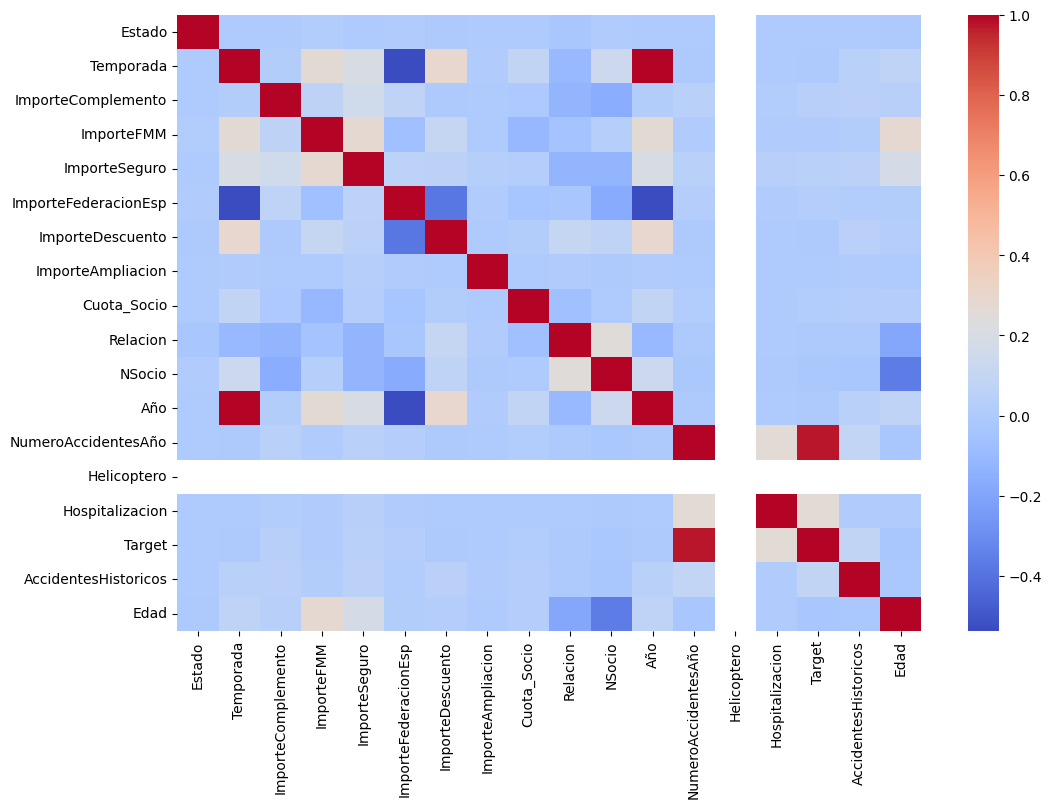

In [19]:
#correlacion variables numericas 
import seaborn as sns
import matplotlib.pyplot as plt

corr = dataset.select_dtypes(include=["int64","float64"]).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [ ]:
dataset

In [21]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117000 entries, 5360 to 112463
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   NIF                            117000 non-null  object        
 1   Nombre                         117000 non-null  object        
 2   Apellido1                      117000 non-null  object        
 3   Apellido2                      116910 non-null  object        
 4   Sexo                           117000 non-null  object        
 5   FechaNacimiento                117000 non-null  datetime64[ns]
 6   PoblacionDomicilio             117000 non-null  object        
 7   DescripcionProvinciaDomicilio  117000 non-null  object        
 8   CodigoPostalDomicilio          117000 non-null  object        
 9   Telefono1                      116875 non-null  object        
 10  Telefono2                      32113 non-null   object        
 11  Em

In [22]:
dataset.columns

Index(['NIF', 'Nombre', 'Apellido1', 'Apellido2', 'Sexo', 'FechaNacimiento',
       'PoblacionDomicilio', 'DescripcionProvinciaDomicilio',
       'CodigoPostalDomicilio', 'Telefono1', 'Telefono2', 'Email', 'Estado',
       'FechaAltaSolicitud', 'NumeroClub', 'DescripcionEntidad', 'Temporada',
       'Modalidad', 'Categoria', 'Complementos', 'ImporteComplemento',
       'ImporteFMM', 'ImporteSeguro', 'ImporteFederacionEsp',
       'ImporteDescuento', 'ImporteAmpliacion', 'Cuota_Socio', 'Relacion',
       'NSocio', 'DireccionDomicilio', 'NIFFamiliar', 'TipoTarjeta', 'Alta',
       'Cuaderno19', 'Bloqueado envÃ­os', 'NCuentaBancaria',
       'Acceso formulario', 'EnvÃ­o tarjeta', 'Discapacidad', 'Año',
       'NumeroAccidentesAño', 'Helicoptero', 'Hospitalizacion', 'Target',
       'AccidentesHistoricos', 'Edad'],
      dtype='object')

In [23]:
dataset_limpio = dataset.drop(['Nombre', 'Apellido1', 'Apellido2','FechaNacimiento','Telefono1', 'Telefono2', 'Email','FechaAltaSolicitud', 'DireccionDomicilio', 'NIFFamiliar', 'Cuaderno19', 'Bloqueado envÃ­os', 'NCuentaBancaria','Acceso formulario'], axis=1)

In [24]:
dataset_limpio.columns

Index(['NIF', 'Sexo', 'PoblacionDomicilio', 'DescripcionProvinciaDomicilio',
       'CodigoPostalDomicilio', 'Estado', 'NumeroClub', 'DescripcionEntidad',
       'Temporada', 'Modalidad', 'Categoria', 'Complementos',
       'ImporteComplemento', 'ImporteFMM', 'ImporteSeguro',
       'ImporteFederacionEsp', 'ImporteDescuento', 'ImporteAmpliacion',
       'Cuota_Socio', 'Relacion', 'NSocio', 'TipoTarjeta', 'Alta',
       'EnvÃ­o tarjeta', 'Discapacidad', 'Año', 'NumeroAccidentesAño',
       'Helicoptero', 'Hospitalizacion', 'Target', 'AccidentesHistoricos',
       'Edad'],
      dtype='object')

In [25]:
dataset_limpio_2 = dataset_limpio.drop(['Sexo','Complementos','ImporteComplemento', 'ImporteFMM', 'ImporteSeguro',
       'ImporteFederacionEsp', 'ImporteDescuento', 'ImporteAmpliacion',
       'Cuota_Socio'], axis=1)

In [26]:
dataset_limpio_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117000 entries, 5360 to 112463
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   NIF                            117000 non-null  object 
 1   PoblacionDomicilio             117000 non-null  object 
 2   DescripcionProvinciaDomicilio  117000 non-null  object 
 3   CodigoPostalDomicilio          117000 non-null  object 
 4   Estado                         117000 non-null  int64  
 5   NumeroClub                     117000 non-null  object 
 6   DescripcionEntidad             117000 non-null  object 
 7   Temporada                      117000 non-null  int64  
 8   Modalidad                      117000 non-null  object 
 9   Categoria                      117000 non-null  object 
 10  Relacion                       117000 non-null  int64  
 11  NSocio                         117000 non-null  int64  
 12  TipoTarjeta                    1

In [27]:
dataset_limpio_2["temporada_federado"] = dataset_limpio_2["Temporada"]

In [ ]:
dataset_limpio_2.drop("Temporada", axis=1)

In [29]:
dataset_limpio_2.columns = dataset_limpio_2.columns.str.lower()

In [30]:
dataset_limpio_2["NIF"] = dataset_limpio_2["nif"]

In [31]:
dataset_limpio_2=dataset_limpio_2.drop("nif",axis=1)
dataset_limpio_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117000 entries, 5360 to 112463
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   poblaciondomicilio             117000 non-null  object 
 1   descripcionprovinciadomicilio  117000 non-null  object 
 2   codigopostaldomicilio          117000 non-null  object 
 3   estado                         117000 non-null  int64  
 4   numeroclub                     117000 non-null  object 
 5   descripcionentidad             117000 non-null  object 
 6   temporada                      117000 non-null  int64  
 7   modalidad                      117000 non-null  object 
 8   categoria                      117000 non-null  object 
 9   relacion                       117000 non-null  int64  
 10  nsocio                         117000 non-null  int64  
 11  tipotarjeta                    117000 non-null  object 
 12  alta                           1

In [32]:
# Quito temporada porque he creado 'temporada_federado'
dataset_limpio_2 = dataset_limpio_2.drop("temporada", axis=1)
dataset_limpio_2.columns

Index(['poblaciondomicilio', 'descripcionprovinciadomicilio',
       'codigopostaldomicilio', 'estado', 'numeroclub', 'descripcionentidad',
       'modalidad', 'categoria', 'relacion', 'nsocio', 'tipotarjeta', 'alta',
       'envã­o tarjeta', 'discapacidad', 'año', 'numeroaccidentesaño',
       'helicoptero', 'hospitalizacion', 'target', 'accidenteshistoricos',
       'edad', 'temporada_federado', 'NIF'],
      dtype='object')

In [ ]:
dataset_limpio_2[["NIF",'poblaciondomicilio', 'descripcionprovinciadomicilio',
       'codigopostaldomicilio', 'temporada_federado', 'categoria', 'edad','estado', 'numeroclub', 'descripcionentidad',
       'modalidad','relacion', 'nsocio', 'tipotarjeta', 'alta',
       'envã­o tarjeta', 'discapacidad', 'año', 'numeroaccidentesaño',
       'helicoptero', 'hospitalizacion', 'target', 'accidenteshistoricos' ]]

In [ ]:
df_2 = pd.read_csv("accidentes_ricardo.csv")
df_2

In [35]:
# Unión de los df de Danilo y Ricardo
# .merge() --- how='outer' 
# conserva todas las filas de ambos dataframes, y las columnas comunes aparecen una sola vez.

columnas_comunes = list(set(dataset_limpio_2.columns) & set(df_2.columns))
df_final = dataset_limpio_2.merge(df_2, on=columnas_comunes, how='outer')

In [36]:
df_final.columns

Index(['poblaciondomicilio', 'descripcionprovinciadomicilio',
       'codigopostaldomicilio', 'estado', 'numeroclub', 'descripcionentidad',
       'modalidad', 'categoria', 'relacion', 'nsocio', 'tipotarjeta', 'alta',
       'envã­o tarjeta', 'discapacidad', 'año', 'numeroaccidentesaño',
       'helicoptero', 'hospitalizacion', 'target', 'accidenteshistoricos',
       'edad', 'temporada_federado', 'NIF', 'Actividad', 'Lugar', 'Provincia',
       'TipoAccidente', 'DescripcionGrado', 'TamañoGrupo', 'NResponsables',
       'Entrenamiento', 'ActividadPersonal', 'ActividadOrganizada', 'Festivo',
       'año_accidente'],
      dtype='object')

In [ ]:
df_final [['NIF','poblaciondomicilio', 'descripcionprovinciadomicilio',
       'codigopostaldomicilio', 'estado', 'numeroclub', 'descripcionentidad',
       'modalidad', 'categoria', 'relacion', 'nsocio', 'tipotarjeta', 'alta',
       'envã­o tarjeta', 'discapacidad', 'año', 'numeroaccidentesaño',
       'helicoptero', 'hospitalizacion', 'target', 'accidenteshistoricos',
       'edad', 'temporada_federado', 'Actividad', 'Lugar', 'Provincia',
       'TipoAccidente', 'DescripcionGrado', 'TamañoGrupo', 'NResponsables',
       'Entrenamiento', 'ActividadPersonal', 'ActividadOrganizada', 'Festivo',
       'año_accidente']]

In [38]:
df_final.to_csv('dataset_prueba.csv', index=False)

In [39]:
df_final.groupby("nsocio")["NIF"].nunique()

nsocio
3        1
12       1
13       1
14       1
18       1
        ..
79900    1
79901    1
79902    1
79903    1
79904    1
Name: NIF, Length: 36959, dtype: int64

In [ ]:
df_final.drop("NIF",axis=1)

In [41]:
df_final= df_final.set_index("nsocio")

In [ ]:
df_final

In [43]:
df_final.columns

Index(['poblaciondomicilio', 'descripcionprovinciadomicilio',
       'codigopostaldomicilio', 'estado', 'numeroclub', 'descripcionentidad',
       'modalidad', 'categoria', 'relacion', 'tipotarjeta', 'alta',
       'envã­o tarjeta', 'discapacidad', 'año', 'numeroaccidentesaño',
       'helicoptero', 'hospitalizacion', 'target', 'accidenteshistoricos',
       'edad', 'temporada_federado', 'NIF', 'Actividad', 'Lugar', 'Provincia',
       'TipoAccidente', 'DescripcionGrado', 'TamañoGrupo', 'NResponsables',
       'Entrenamiento', 'ActividadPersonal', 'ActividadOrganizada', 'Festivo',
       'año_accidente'],
      dtype='object')

In [44]:
df_final = df_final.drop(["poblaciondomicilio", "estado", 'descripcionprovinciadomicilio', "descripcionentidad","relacion",
                          "tipotarjeta", "alta", 'envã­o tarjeta', "año","NIF"], axis=1)

In [45]:
df_final

,codigopostaldomicilio,numeroclub,modalidad,categoria,discapacidad,numeroaccidentesaño,helicoptero,hospitalizacion,target,accidenteshistoricos,...,Provincia,TipoAccidente,DescripcionGrado,TamañoGrupo,NResponsables,Entrenamiento,ActividadPersonal,ActividadOrganizada,Festivo,año_accidente
nsocio,,,,,,,,,,,,,,,,,,,,,
59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,28043,07.28.012,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78946,28080,07.28.475,AU,Mayor Mujer,NO,0.0,0.0,0.0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79253,28045,07.28.370,B,Mayor Mujer,NO,0.0,0.0,0.0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78924,28016,07.28.000,C,Mayor Mujer,NO,0.0,0.0,0.0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
df_final.to_csv('dataset_definitivo.csv')

In [50]:
df_final.sample(100).to_csv("muestra_dataset.csv")

In [ ]:
"C:\Users\Arrate\Documents\GitHub\prediccion_accidentes_federacion_monta-a\src\data_sample\data_sample.csv"